# OPCal image processing - caiman implementation

### Overview

This Python script provides a complete pipeline for analyzing calcium imaging data from OPCs using the CaImAn framework. It includes tools for preprocessing TIFF files, running CNMF for source extraction, and exporting the results in COCO format for machine learning applications.

### Set video path

In [ ]:
import os

# 1) Path to the original multi-frame TIFF
video_path = r'C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO.tif'

# 2) Derive base folder (where the TIFF lives) and a base name
base_dir  = os.path.dirname(video_path)                                  # folder containing the TIFF
base_name = os.path.splitext(os.path.basename(video_path))[0]            # "20250409_1_ATP_100uM_TIF_VIDEO"

# 3) Chunks go under the same folder (you can change the name if you like)
chunks_folder = os.path.join(base_dir, "chunks")
os.makedirs(chunks_folder, exist_ok=True)

# 4) All COCO outputs (JSON, masks, viz, CSV) will be saved NEXT TO the TIFF
coco_base = base_dir
os.makedirs(coco_base, exist_ok=True)

# 5) Crops go into accepted/… and rejected/… subtrees
CROP_DIRS = {
    "accepted": {
        "tight":  os.path.join(coco_base, "accepted", "raw_crops"),
        "zoomed": os.path.join(coco_base, "accepted", "raw_crops_zoomed_out"),
    },
    "rejected": {
        "tight":  os.path.join(coco_base, "rejected", "raw_crops"),
        "zoomed": os.path.join(coco_base, "rejected", "raw_crops_zoomed_out"),
    }
}
# create all four folders
for status in CROP_DIRS:
    for kind in CROP_DIRS[status].values():
        os.makedirs(kind, exist_ok=True)

# 6) Optional: choose an output JSON filename based on the TIFF name
output_file_name = f"{base_name}_coco.json"

print("Outputs will be written to:", coco_base)
print("Crop folders:", CROP_DIRS)

Outputs will be written to: C:\Users\kiril\Desktop\OPCal\Tal&Meital code
Crop folders: {'accepted': {'tight': 'C:\\Users\\kiril\\Desktop\\OPCal\\Tal&Meital code\\accepted\\raw_crops', 'zoomed': 'C:\\Users\\kiril\\Desktop\\OPCal\\Tal&Meital code\\accepted\\raw_crops_zoomed_out'}, 'rejected': {'tight': 'C:\\Users\\kiril\\Desktop\\OPCal\\Tal&Meital code\\rejected\\raw_crops', 'zoomed': 'C:\\Users\\kiril\\Desktop\\OPCal\\Tal&Meital code\\rejected\\raw_crops_zoomed_out'}}


In [ ]:
Ask Adam about this part

# import caiman as cm
# from pathlib import Path

# # --- choose a tile (1/16th example: middle-left) ---
# m0 = cm.load(video_path)                 # (T, d1, d2)
# T, d1, d2 = m0.shape
# # pick any tile; here: rows [d1//4 : d1//2], cols [d2//4 : d2//2]
# y0, y1 = d1//4, d1//2
# x0, x1 = d2//4, d2//2

# # add a guard margin so MC & patches aren’t cramped
# margin = max(2*int(gSiz[0]), 32)       # ~2× spatial window or ~32 px
# y0 = max(0, y0 - margin); y1 = min(d1, y1 + margin)
# x0 = max(0, x0 - margin); x1 = min(d2, x1 + margin)

# m_crop = m0[:, y0:y1, x0:x1]           # NO frame skipping, just spatial crop

# # save a small temporary file and point CaImAn at it
# tmp_path = str(Path(video_path).with_name(f'proto_crop_{y0}_{y1}_{x0}_{x1}.tif'))
# m_crop.save(tmp_path)

# # use the crop for the whole run
# video_path = tmp_path


### Imports and general setup

Loading BokehJS ...

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
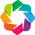

In [2]:
import bokeh.plotting as bpl
import datetime
import glob
import holoviews as hv
from IPython import get_ipython
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import psutil
from pathlib import Path
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

try:
    cv2.setNumThreads(0)
except():
    pass

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

import caiman as cm
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import cnmf, params
from caiman.utils.utils import download_demo
from caiman.utils.visualization import plot_contours, nb_view_patches, nb_plot_contour
from caiman.utils.visualization import nb_view_quilt

bpl.output_notebook()
hv.notebook_extension('bokeh')

# set up logging
logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

# set env variables
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"



### Visualize data

Generates and plots the maximum intensity projection and local correlation image for an initial inspection of the calcium imaging data.

100%|██████████| 1/1 [00:00<00:00,  1.13it/s]


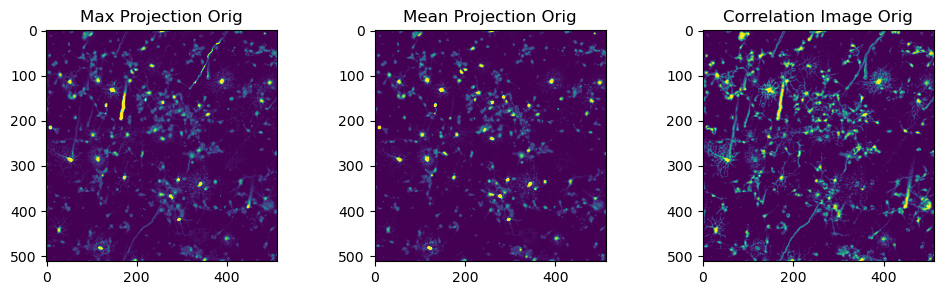

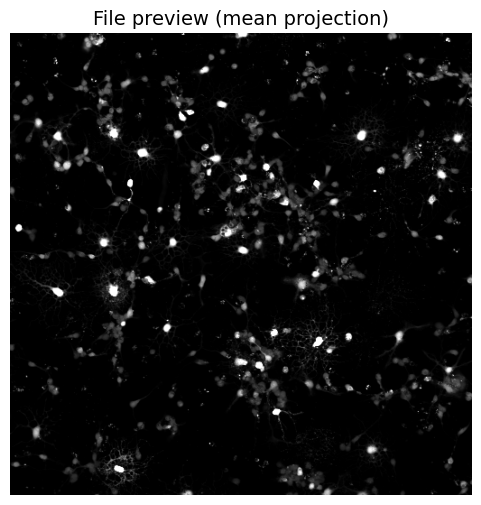

In [6]:
movie = cm.load_movie_chain([video_path])

max_projection_orig = np.max(movie, axis=0)
mean_projection = np.mean(movie, axis=0)
correlation_image_orig = cm.local_correlations(movie, swap_dim=False)
correlation_image_orig[np.isnan(correlation_image_orig)] = 0 # get rid of NaNs, if they exist

f, (ax_max, ax_mean, ax_corr) = plt.subplots(1,3,figsize=(12,3))
ax_max.imshow(max_projection_orig,
              cmap='viridis',
              vmin=np.percentile(np.ravel(max_projection_orig),50),
              vmax=np.percentile(np.ravel(max_projection_orig),99.5))
ax_max.set_title("Max Projection Orig", fontsize=12)

ax_mean.imshow(mean_projection,
              cmap='viridis',
              vmin=np.percentile(np.ravel(mean_projection),50),
              vmax=np.percentile(np.ravel(mean_projection),99.5))
ax_mean.set_title("Mean Projection Orig", fontsize=12)

ax_corr.imshow(correlation_image_orig,
               cmap='viridis',
               vmin=np.percentile(np.ravel(correlation_image_orig),50),
               vmax=np.percentile(np.ravel(correlation_image_orig),99.5))
ax_corr.set_title('Correlation Image Orig', fontsize=12)

#save mean projection for later
vmin = np.percentile(mean_projection, 50)
vmax = np.percentile(mean_projection, 99.5)
mean_proj_norm = np.clip((mean_projection - vmin) / (vmax - vmin), 0, 1)

#File preview
plt.figure(figsize=(6, 6))
plt.imshow(mean_proj_norm, cmap='gray')
plt.title("File preview (mean projection)", fontsize=14)
plt.axis('off')
plt.show()

### Set initial parameters

In [32]:
# --- OPC geometry & sampling ---
fr = 1.08
decay_time = 20
dxy = (1.243, 1.243)                 # µm/px
cell_diameter = 10                   # µm (OPC soma, mouse)
d_px = int(round(cell_diameter / dxy[0]))   # ~8 px
gSig = np.array([int(round(0.5*d_px))]*2)   # ~4 px
gSiz = 2*gSig + 1                            

# --- Stage 1 (FIT): cast a controlled-wide net (fewer dupes than before) ---
stage1_params_dict = {
    'fnames': video_path,
    'fr': fr, 'dxy': dxy, 'decay_time': decay_time, 'p': 2,
    'nb': 2,
    'rf': int(2*d_px),                 # patch half-size
    'stride': int(1.0*d_px),           # a tad larger stride → less patch overlap → fewer duplicates
    'K': 4,                            # fewer seeds than 12 to reduce speckles
    'gSig': gSig, 'gSiz': gSiz,
    'method_init': 'greedy_roi',
    'min_corr': 0.90,           # try 0.90–0.95; raise to be stricter
    'min_pnr': 12,              # try 12–20; raise if you still get junk
    'ring_size_factor': 1.5,    # 1.4–1.7 typically good for neuropil
    'remove_very_bad_comps': True,
    'rolling_sum': True,
    'only_init': True,
    'ssub': 1, 'tsub': 1,
    'merge_thr': 0.7, #was 0.2
    'bas_nonneg': True,
    'min_SNR': 2.0,                    # moderate gate
    'rval_thr': 0.85,                  # moderate gate
    'use_cnn': False, 'min_cnn_thr': 0.0, 'cnn_lowest': 0.0,
    'p' : 2,
}

# --- Stage 2 (REFIT): polish/prune (no patches; stricter quality) ---
stage2_tighten = {
    'patch':   {'rf': None, 'stride': None, 'only_init': False},  # full FOV
    'quality': {'min_SNR': 3.0, 'rval_thr': 0.9},                # stricter after refinement
}


In [33]:
from skimage import measure
import numpy as np

def roi_mask_and_area(A_col, dims, thr=0.20):
    """Return (mask_bool, area_px) using a per-ROI relative threshold."""
    d1, d2 = dims
    im = A_col.toarray().ravel(order='F').reshape(d1, d2, order='F')
    vmax = im.max()
    if vmax <= 0:
        return np.zeros((d1,d2), bool), 0
    mask = im >= (thr * vmax)
    return mask, int(mask.sum())

def iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    if inter == 0:
        return 0.0
    uni = np.logical_or(m1, m2).sum()
    return float(inter) / float(uni)

def size_and_overlap_prune(cnm, d_px, thr=0.20, area_lo_factor=0.6, area_hi_factor=2.2, iou_thr=0.60):
    """
    Keep components within [area_lo, area_hi] and de-duplicate masks with high IoU.
    Score = prefer higher SNR (if available), else larger area.
    """
    d1, d2 = cnm.estimates.dims
    A = cnm.estimates.A.tocsc()
    K = A.shape[1]

    # expected OPC soma area (circle with diameter d_px)
    expected_area = np.pi * (0.5*d_px)**2
    area_lo = int(round(area_lo_factor * expected_area))   # strict low bound
    area_hi = int(round(area_hi_factor * expected_area))   # strict high bound

    masks = []
    areas = np.zeros(K, int)
    keep = np.zeros(K, bool)

    for k in range(K):
        m, a = roi_mask_and_area(A.getcol(k), (d1, d2), thr=thr)
        masks.append(m)
        areas[k] = a
        keep[k] = (a >= area_lo) and (a <= area_hi)

    # Prefer higher SNR (if evaluated), else area
    snr = getattr(cnm.estimates, 'snr_comp', None)
    scores = (snr if snr is not None else areas).astype(float)

    # Greedy NMS by score
    idx_sorted = np.argsort(-scores)
    selected = []
    used = np.zeros(K, bool)
    for k in idx_sorted:
        if not keep[k] or used[k]:
            continue
        mk = masks[k]
        ok = True
        for s in selected:
            if iou(mk, masks[s]) >= iou_thr:
                ok = False
                break
        if ok:
            selected.append(k)
            used[k] = True

    selected = np.array(sorted(selected), dtype=int)
    rejected = np.setdiff1d(np.arange(K), selected, assume_unique=False)

    # Update cnm indices for downstream steps
    cnm.estimates.idx_components = selected
    cnm.estimates.idx_components_bad = rejected

    # Handy for logging
    return dict(selected=selected, rejected=rejected,
                area_lo=area_lo, area_hi=area_hi, iou_thr=iou_thr)


### Set up multicore processing

Automatically configures parallel processing using available CPU cores to speed up CNMF fitting.

In [34]:
print(f"You have {psutil.cpu_count()} CPUs available in your current environment")
num_processors_to_use = None

if 'cluster' in locals():  # 'locals' contains list of current local variables
    print('Closing previous cluster')
    cm.stop_server(dview=cluster)
print("Setting up new cluster")
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                   n_processes=num_processors_to_use,
                                                   ignore_preexisting=False)
print(f"Successfully initilialized multicore processing with a pool of {n_processes} CPU cores")

You have 8 CPUs available in your current environment
Closing previous cluster
Setting up new cluster
Successfully initilialized multicore processing with a pool of 7 CPU cores


### Creating and accessing memory mapped files

Converts the TIFF video to a memory-mapped format for efficient reading.

In [51]:
import datetime

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
base_name = f'memmap_{timestamp}_'

mc_memmapped_fname = cm.save_memmap(
    [video_path],
    base_name=base_name,  # <--- USE the variable here
    order='C',
    border_to_0=0,
    dview=cluster,
    #n_chunks=20
)


In [52]:
Yr, dims, num_frames = cm.load_memmap(mc_memmapped_fname)
images = np.reshape(Yr.T, [num_frames] + list(dims), order='F') #reshape frames in standard 3d format (T x X x Y)



In [53]:
cm.stop_server(dview=cluster)
_, cluster, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                   n_processes=num_processors_to_use,
                                                   single_thread=False)

### cNMF segmentation

Performs source extraction

In [54]:
# Build models
parameters_stage1 = params.CNMFParams(params_dict=stage1_params_dict)
cnmf_model = cnmf.CNMF(n_processes=int(n_processes),
                       params=parameters_stage1)

     5829131 [params.py:       change_params():1156] [90180] In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


In [55]:
import time, os

t0 = time.time()
cnm = cnmf_model.fit(images)                          # dview optional with multiprocessing
print(f"Stage-1 fit done in {(time.time()-t0)/60:.1f} min, K={cnm.estimates.A.shape[1]} raw comps.")

# checkpoint after fit (so you never refit if later steps fail)
stage1_ckpt = os.path.join(coco_base, "cnm_stage1_fit.hdf5")
cnm.save(stage1_ckpt)
print("Saved:", stage1_ckpt)


c:\Users\kiril\anaconda3\envs\caiman_env\lib\site-packages\caiman\source_extraction\cnmf\deconvolution.py:1004: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[lags + np.arange(lags)],


Stage-1 fit done in 4.8 min, K=649 raw comps.
Saved: C:\Users\kiril\Desktop\OPCal\Tal&Meital code\cnm_stage1_fit.hdf5


In [56]:
t0 = time.time()
cnm.estimates.evaluate_components(images, cnm.params, dview=cluster if 'cluster' in globals() else None)
log1 = size_and_overlap_prune(cnm, d_px=d_px, thr=0.20,
                              area_lo_factor=0.60, area_hi_factor=2.2, iou_thr=0.60)
print(f"Eval+prune1 kept {len(log1['selected'])} / {cnm.estimates.A.shape[1]} in {(time.time()-t0):.1f}s")
print(f"Area gate px: [{log1['area_lo']},{log1['area_hi']}], IoU={log1['iou_thr']}")

# optional checkpoint after pruning
stage1_post_ckpt = os.path.join(coco_base, "cnm_stage1_postprune.hdf5")
cnm.save(stage1_post_ckpt)
print("Saved:", stage1_post_ckpt)


Eval+prune1 kept 185 / 649 in 32.7s
Area gate px: [30,111], IoU=0.6
Saved: C:\Users\kiril\Desktop\OPCal\Tal&Meital code\cnm_stage1_postprune.hdf5


In [57]:
# tighten refit params (you defined stage2_tighten earlier)
cnm.params.change_params(params_dict=stage2_tighten)

t0 = time.time()
cnm = cnm.refit(images, dview=cluster if 'cluster' in globals() else None)
print(f"Refit done in {(time.time()-t0)/60:.1f} min, comps still tracked: {cnm.estimates.A.shape[1]}")

stage2_ckpt = os.path.join(coco_base, "cnm_stage2_refit.hdf5")
cnm.save(stage2_ckpt)
print("Saved:", stage2_ckpt)


*** Variable cnn_preds has not the same number of components as A ***
Refit done in 2.2 min, comps still tracked: 181
Saved: C:\Users\kiril\Desktop\OPCal\Tal&Meital code\cnm_stage2_refit.hdf5


In [58]:
t0 = time.time()
cnm.estimates.evaluate_components(images, cnm.params, dview=cluster if 'cluster' in globals() else None)
log2 = size_and_overlap_prune(cnm, d_px=d_px, thr=0.20,
                              area_lo_factor=0.60, area_hi_factor=2.2, iou_thr=0.60)
print(f"Eval+prune2 kept {len(log2['selected'])} / {cnm.estimates.A.shape[1]} in {(time.time()-t0):.1f}s")

final_cnm = cnm
final_ckpt = os.path.join(coco_base, "cnm_final.hdf5")
final_cnm.save(final_ckpt)
print("Saved:", final_ckpt)


Eval+prune2 kept 155 / 181 in 4.6s
Saved: C:\Users\kiril\Desktop\OPCal\Tal&Meital code\cnm_final.hdf5



### Saving Results in a COCO Format ###

In [59]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

def add_fixed_scalebar(ax, pixel_size_um=1.243, bar_length_um=10):
    length_pixels = bar_length_um / pixel_size_um
    scalebar = AnchoredSizeBar(ax.transData,
                                length_pixels,
                                f'{bar_length_um} µm',
                                loc='lower left',
                                pad=0.3,
                                color='white',
                                frameon=False,
                                size_vertical=1)
    ax.add_artist(scalebar)


In [60]:
def process_component(idx, annotation_id, status,
                      A, height, width, projection_frame, dxy,
                      crop_dirs, coco_output, binary_sum, yy, xx,
                      image_id, csv_rows):
    """
    Standalone version used by save_as_coco_extended.
    Computes bbox from the drawn contour (not an arbitrary region),
    so tight crops never come out blank.
    """
    comp = A[:, idx].toarray().reshape(height, width, order='F')
    vmax = float(comp.max())
    if vmax <= 0:
        return annotation_id

    thr = 0.1 * vmax
    mask = comp > thr
    binary_sum[mask] = 255

    contours = measure.find_contours(comp, thr)
    if not contours:
        return annotation_id

    # Longest contour = what we actually draw
    contour = sorted(contours, key=len)[-1]
    segmentation = [float(val) for pt in contour for val in (pt[1], pt[0])]

    # --- bbox from the SAME contour (fix) ---
    rmin = int(np.floor(contour[:, 0].min()))
    rmax = int(np.ceil( contour[:, 0].max()))
    cmin = int(np.floor(contour[:, 1].min()))
    cmax = int(np.ceil( contour[:, 1].max()))

    # Tight, unpadded bbox for annotation
    bbox = [float(cmin), float(rmin), float(cmax - cmin), float(rmax - rmin)]
    area = float(mask.sum())

    # Intensity-weighted centroid over full component
    total = float(comp.sum())
    cy = float((comp * yy).sum() / total) if total > 0 else float('nan')
    cx = float((comp * xx).sum() / total) if total > 0 else float('nan')

    # Append annotation
    coco_output["annotations"].append({
        "id": annotation_id,
        "image_id": image_id,
        "category_id": 1,
        "segmentation": [segmentation],
        "area": area,
        "bbox": bbox,
        "iscrowd": 0
    })

    # --- padded crop window (clip to image) ---
    pad = 10
    minr_pad = max(rmin - pad, 0)
    maxr_pad = min(rmax + pad, height)
    minc_pad = max(cmin - pad, 0)
    maxc_pad = min(cmax + pad, width)

    # guard: empty slice?
    if (maxr_pad <= minr_pad) or (maxc_pad <= minc_pad):
        return annotation_id + 1

    # ── TIGHT crop (status-specific folder) ──
    raw_crop = projection_frame[minr_pad:maxr_pad, minc_pad:maxc_pad].copy()
    fig, ax = plt.subplots()
    ax.imshow(raw_crop, cmap='gray', origin='upper', interpolation='nearest')
    ax.plot(contour[:, 1] - minc_pad, contour[:, 0] - minr_pad, color='red', linewidth=1)
    ax.set_xlim(0, raw_crop.shape[1]); ax.set_ylim(raw_crop.shape[0], 0)  # ensure full canvas covers image
    add_fixed_scalebar(ax, pixel_size_um=dxy[0])
    ax.axis('off')
    tight_path = os.path.join(crop_dirs[status]["tight"], f"component_{idx}.png")
    fig.savefig(tight_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig)

    # ── ZOOMED crop (status-specific folder) ──
    center_r = (minr_pad + maxr_pad) // 2
    center_c = (minc_pad + maxc_pad) // 2
    h = maxr_pad - minr_pad
    w = maxc_pad - minc_pad
    half_h_large = (h * 5) // 2
    half_w_large = (w * 5) // 2

    new_minr = max(0, center_r - half_h_large)
    new_maxr = min(height, center_r + half_h_large)
    new_minc = max(0, center_c - half_w_large)
    new_maxc = min(width, center_c + half_w_large)

    raw_crop_zoomed = projection_frame[new_minr:new_maxr, new_minc:new_maxc].copy()
    fig2, ax2 = plt.subplots(figsize=(4, 4))
    ax2.imshow(raw_crop_zoomed, cmap='gray', origin='upper', interpolation='nearest')
    contour_rescaled = np.column_stack([contour[:, 0] - new_minr, contour[:, 1] - new_minc])
    ax2.plot(contour_rescaled[:, 1], contour_rescaled[:, 0], color='red', linewidth=1)
    ax2.set_xlim(0, raw_crop_zoomed.shape[1]); ax2.set_ylim(raw_crop_zoomed.shape[0], 0)
    add_fixed_scalebar(ax2, pixel_size_um=dxy[0])
    ax2.axis('off')
    zoomed_path = os.path.join(crop_dirs[status]["zoomed"], f"component_{idx}_zoomed.png")
    fig2.savefig(zoomed_path, bbox_inches='tight', pad_inches=0)
    plt.close(fig2)

    # CSV row (unchanged fields)
    csv_rows.append({
        "roi_id": int(idx),
        "status": status,
        "cx": cx, "cy": cy,
        "bbox_x": float(cmin), "bbox_y": float(rmin),
        "bbox_w": float(cmax - cmin), "bbox_h": float(rmax - rmin),
        "area_px": int(area),
        "contour_thr": float(thr)
    })

    return annotation_id + 1


In [61]:
from skimage import measure
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import datetime
import csv

def save_as_coco_extended(cnmf_results, output_file_name, projection_frame, frame_rate, image_id=1, crop_dirs=None):
    """
    Saves next to the original TIFF (coco_base):
      - COCO JSON annotations (output_file_name)
      - Summary mask and visualization PNGs
      - Estimated & raw calcium traces JSON
      - ROI coordinates CSV: <base>_roi_coordinates.csv
      - Crops into accepted/… and rejected/… subfolders:
          accepted/raw_crops, accepted/raw_crops_zoomed_out,
          rejected/raw_crops, rejected/raw_crops_zoomed_out

    Requires global: coco_base
    Optionally pass crop_dirs (dict like CROP_DIRS above). If None, it will be created under coco_base.
    """
    assert 'coco_base' in globals(), "Define coco_base (folder next to the TIFF) before calling."

    height, width = projection_frame.shape
    first_frame = projection_frame.copy()

    # ---- Output paths (all live next to the TIFF) ----
    coco_json_path         = os.path.join(coco_base, output_file_name)
    base_name              = os.path.splitext(output_file_name)[0]
    summary_mask_path      = os.path.join(coco_base, f"{base_name}_summary_binary_mask.png")
    visualization_path     = os.path.join(coco_base, f"{base_name}_visualization.png")
    rejected_size_list     = os.path.join(coco_base, f"{base_name}_rejected_due_to_size.json")
    estimated_calcium_json = os.path.join(coco_base, f"{base_name}_estimated_calcium.json")
    raw_calcium_json       = os.path.join(coco_base, f"{base_name}_raw_calcium.json")
    roi_csv_path           = os.path.join(coco_base, f"{base_name}_roi_coordinates.csv")  # NEW

    # ---- Crop directories (accepted/rejected; tight/zoomed) ----
    if crop_dirs is None:
        crop_dirs = {
            "accepted": {
                "tight":  os.path.join(coco_base, "accepted", "raw_crops"),
                "zoomed": os.path.join(coco_base, "accepted", "raw_crops_zoomed_out"),
            },
            "rejected": {
                "tight":  os.path.join(coco_base, "rejected", "raw_crops"),
                "zoomed": os.path.join(coco_base, "rejected", "raw_crops_zoomed_out"),
            }
        }
    for status in crop_dirs:
        for p in crop_dirs[status].values():
            os.makedirs(p, exist_ok=True)

    # ---- CNMF estimates ----
    A   = cnmf_results.estimates.A.tocsc()
    C   = cnmf_results.estimates.C
    YrA = cnmf_results.estimates.YrA
    RawC = C + YrA

    idx_acc = getattr(cnmf_results.estimates, "idx_components", None)
    idx_bad = getattr(cnmf_results.estimates, "idx_components_bad", None)

    accepted = list(map(int, idx_acc)) if (idx_acc is not None and len(idx_acc) > 0) else list(range(A.shape[1]))
    rejected = list(map(int, idx_bad)) if idx_bad is not None else []

    binary_sum = np.zeros((height, width), dtype=np.uint8)

    coco_output = {
        "info": {
            "description": "OPC data from CaImAn analysis",
            "version": "1.0",
            "year": int(datetime.datetime.now().year),
            "contributor": "CaImAn-OPCal",
            "date_created": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        },
        "licenses": [{"id": 1, "name": "Unknown", "url": ""}],
        "categories": [{"id": 1, "name": "OPC", "supercategory": "cell"}],
        "images": [{
            "id": image_id,
            "width": width,
            "height": height,
            "file_name": f"frame_{image_id}.png",
            "license": 1
        }],
        "annotations": []
    }

    # ---- Spatial calibration & size filter ----
    dxy = (1.243, 1.243)  # µm/px
    cell_diameter = 10    # µm
    d_px = int(cell_diameter // dxy[0])
    min_area_px = (np.pi * (d_px / 2) ** 2) / 2

    filtered_accepted = []
    for idx in accepted:
        comp = A[:, idx].toarray().reshape(height, width, order='F')
        if np.sum(comp > 0.1 * comp.max()) >= min_area_px:
            filtered_accepted.append(idx)
        else:
            rejected.append(idx)
    accepted = filtered_accepted
    rejected = sorted(set(rejected))

    with open(rejected_size_list, 'w') as f:
        json.dump(rejected, f)
    print(f"Saved rejected‐due‐to‐size list → {rejected_size_list}")

    # ---- CSV setup (NEW) ----
    csv_rows = []
    yy, xx = np.indices((height, width))

    annotation_id = 1

    # Build outputs
    for idx in accepted:
        annotation_id = process_component(idx, annotation_id, status="accepted",
                                      A=A, height=height, width=width,
                                      projection_frame=projection_frame, dxy=dxy,
                                      crop_dirs=crop_dirs, coco_output=coco_output,
                                      binary_sum=binary_sum, yy=yy, xx=xx,
                                      image_id=image_id, csv_rows=csv_rows)

    for idx in rejected:
        annotation_id = process_component(idx, annotation_id, status="rejected",
                                      A=A, height=height, width=width,
                                      projection_frame=projection_frame, dxy=dxy,
                                      crop_dirs=crop_dirs, coco_output=coco_output,
                                      binary_sum=binary_sum, yy=yy, xx=xx,
                                      image_id=image_id, csv_rows=csv_rows)

    # Summary mask
    Image.fromarray(binary_sum).save(summary_mask_path)

    # Visualization
    plt.figure(figsize=(10, 10))
    plt.imshow(first_frame, cmap='gray')
    for idx in accepted:
        comp = A[:, idx].toarray().reshape(height, width, order='F')
        thr = 0.1 * float(comp.max())
        for contour in measure.find_contours(comp, thr):
            plt.plot(contour[:, 1], contour[:, 0], linewidth=0.6, color='green')
    for idx in rejected:
        comp = A[:, idx].toarray().reshape(height, width, order='F')
        thr = 0.1 * float(comp.max())
        for contour in measure.find_contours(comp, thr):
            plt.plot(contour[:, 1], contour[:, 0], linewidth=0.6, color='red')
    plt.title(f"COCO Segmentation: {len(accepted)} accepted / {len(rejected)} rejected")
    plt.axis('off')
    plt.savefig(visualization_path)
    plt.close()

    # COCO JSON
    with open(coco_json_path, 'w') as f:
        json.dump(coco_output, f)

    # Calcium traces
    time_points = np.linspace(0, C.shape[1] / frame_rate, C.shape[1])
    calcium_data = {"time": list(time_points)}
    raw_data = {"time": list(time_points)}
    for idx in range(C.shape[0]):
        calcium_data[f"component_{idx}"] = list(C[idx])
        raw_data[f"component_{idx}"] = list(RawC[idx])
    with open(estimated_calcium_json, 'w') as f:
        json.dump(calcium_data, f)
    with open(raw_calcium_json, 'w') as f:
        json.dump(raw_data, f)

    # ROI CSV (header-only if empty)
    if len(csv_rows) == 0:
        header = ["roi_id","status","cx","cy","bbox_x","bbox_y","bbox_w","bbox_h",
                  "area_px","contour_thr"]
        with open(roi_csv_path, "w", newline="") as f:
            csv.writer(f).writerow(header)
    else:
        with open(roi_csv_path, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(csv_rows[0].keys()))
            writer.writeheader()
            writer.writerows(csv_rows)

    print(f"Saved COCO JSON → {coco_json_path}")
    print(f"Summary map → {summary_mask_path}")
    print(f"Visualization → {visualization_path}")
    print(f"Estimated Ca traces → {estimated_calcium_json}")
    print(f"Raw Ca traces → {raw_calcium_json}")
    print(f"ROI coordinates CSV → {roi_csv_path}")
    print("Crops:")
    for status in crop_dirs:
        print(f"  {status}: tight → {crop_dirs[status]['tight']} | zoomed → {crop_dirs[status]['zoomed']}")

    return coco_output


In [62]:
def export_to_coco_extended(cnmf_results, file_path, background_img, frame_rate=1.08):
    output_file = os.path.splitext(file_path)[0] + '_coco.json'
    return save_as_coco_extended(cnmf_results, output_file, background_img, frame_rate)

In [63]:
export_to_coco_extended(cnmf_results=final_cnm, file_path=video_path, background_img=mean_o)

Saved rejected‐due‐to‐size list → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_rejected_due_to_size.json
Saved COCO JSON → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco.json
Summary map → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_summary_binary_mask.png
Visualization → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_visualization.png
Estimated Ca traces → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_estimated_calcium.json
Raw Ca traces → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_raw_calcium.json
ROI coordinates CSV → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\20250409_3_Glut_1mM_TIF_VIDEO_coco_roi_coordinates.csv
Crops:
  accepted: tight → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\accepted\raw_crops | zoomed → C:\Users\kiril\Desktop\OPCal\Tal&Meital code\accepted\raw_crops

{'info': {'description': 'OPC data from CaImAn analysis',
  'version': '1.0',
  'year': 2026,
  'contributor': 'CaImAn-OPCal',
  'date_created': '2026-02-15 19:24:18'},
 'licenses': [{'id': 1, 'name': 'Unknown', 'url': ''}],
 'categories': [{'id': 1, 'name': 'OPC', 'supercategory': 'cell'}],
 'images': [{'id': 1,
   'width': 512,
   'height': 512,
   'file_name': 'frame_1.png',
   'license': 1}],
 'annotations': [{'id': 1,
   'image_id': 1,
   'category_id': 1,
   'segmentation': [[237.0,
     23.11755078811745,
     236.0,
     23.922671516242353,
     235.0,
     23.998777079714692,
     234.0,
     23.998777079714692,
     233.0,
     23.63685757060567,
     232.36314242939434,
     23.0,
     232.0,
     22.63685757060567,
     231.48378191140503,
     22.0,
     231.1906878073942,
     21.0,
     231.1906878073942,
     20.0,
     231.41645032880322,
     19.0,
     232.0,
     18.236648087363907,
     232.2366480873639,
     18.0,
     233.0,
     17.236648087363907,
     233.544